--- BẮT ĐẦU CHẠY PIPELINE ---
Đã tải thành công! Kích thước dữ liệu: (1460, 82)
Đang làm sạch dữ liệu...
-> Đã làm sạch xong!
Đang vẽ 5 biểu đồ EDA...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14144\4287555745.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=self.df, palette='viridis')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14144\4287555745.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='MSZoning', data=self.df, palette='Set2')


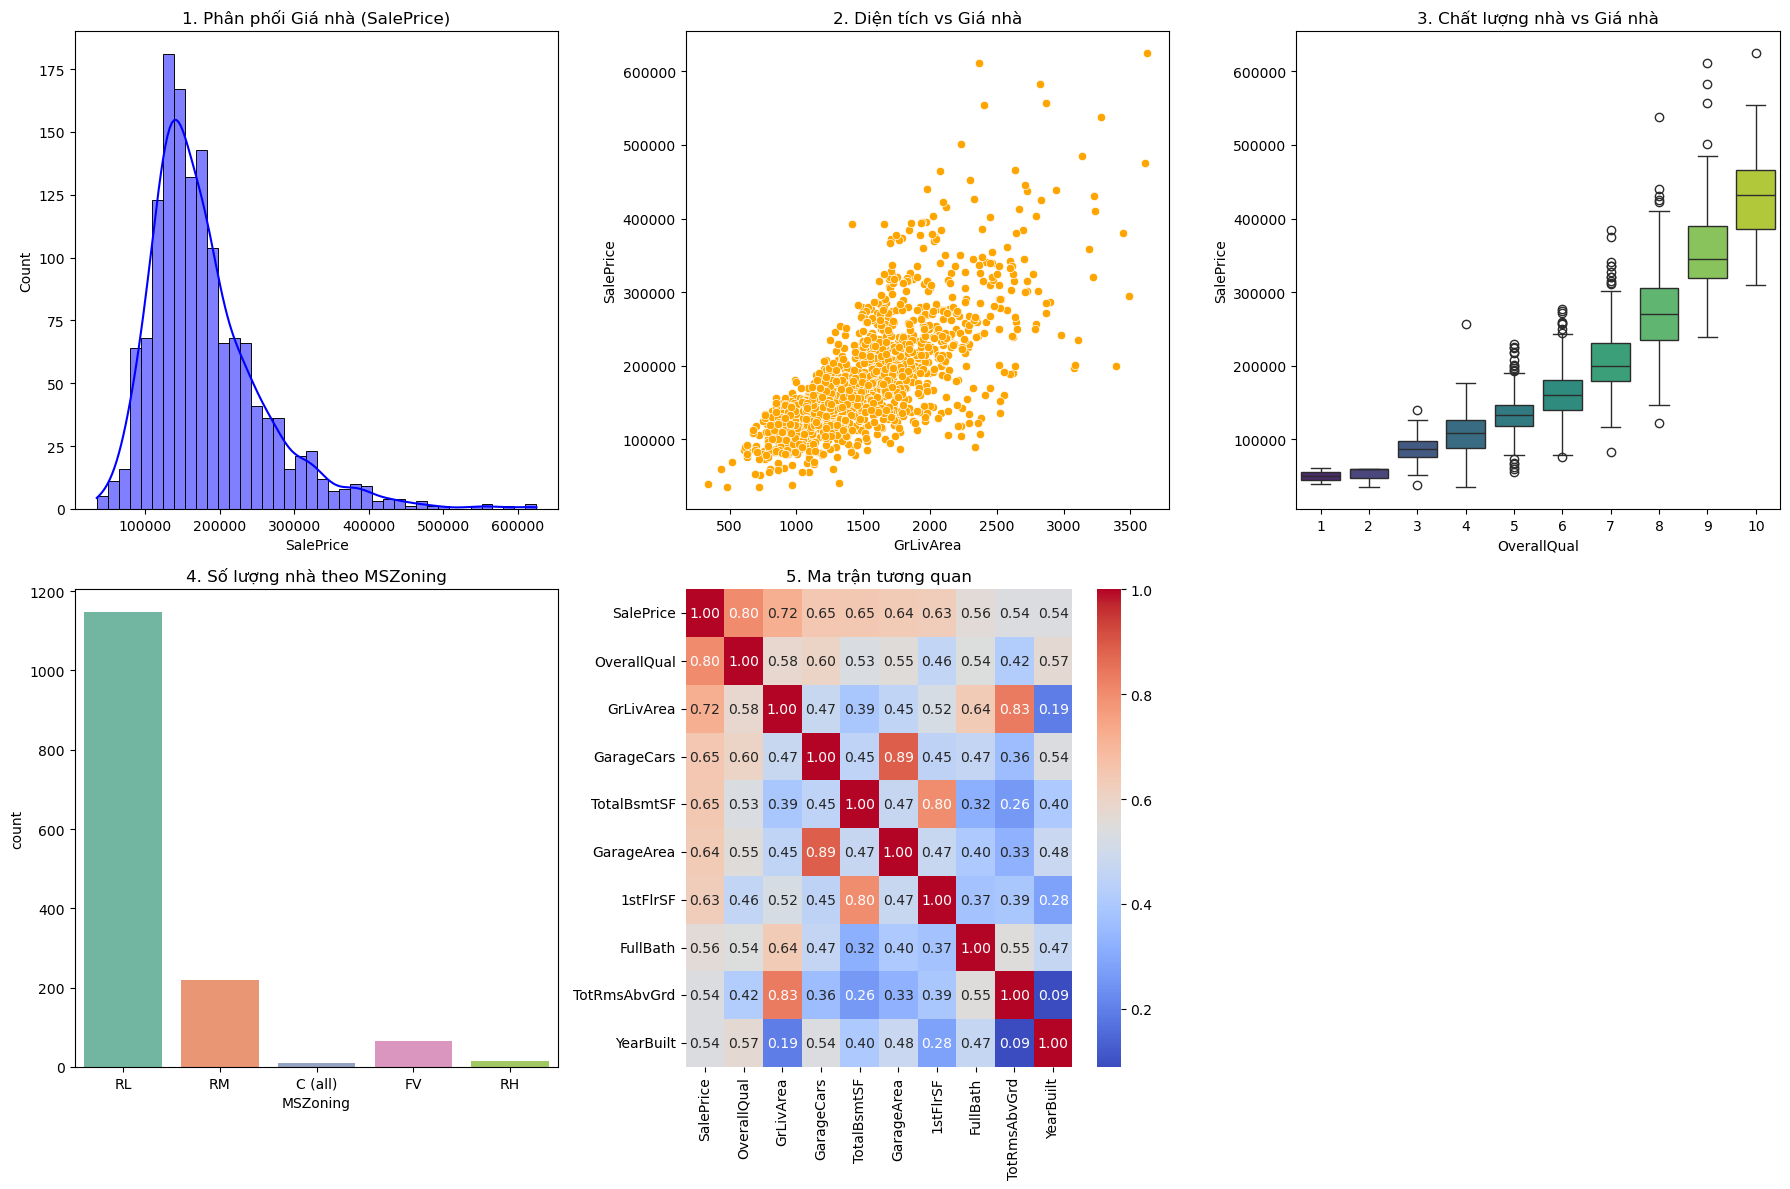

Đang chuẩn bị dữ liệu cho Machine Learning...
-> Đã chia tập Train/Test. Kích thước Train: (1164, 79)
Đang huấn luyện mô hình...

--- 1. KẾT QUẢ LINEAR REGRESSION ---
R2 Score: 0.8856
MAE: 18,211 USD
RMSE: 24,507 USD

--- 2. KẾT QUẢ RANDOM FOREST ---
R2 Score: 0.8853
MAE: 16,780 USD
RMSE: 24,533 USD

[OK] Đã xuất mô hình AI thành công ra file model.pkl!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

# ==========================================
# 1. LỚP XỬ LÝ DỮ LIỆU (Dành cho Ngọc)
# ==========================================
class HouseDataPipeline:
    def __init__(self, csv_path, json_path):
        self.csv_path = csv_path
        self.json_path = json_path
        self.df = None
        self.zone_dict = {}

    def load_and_merge_data(self):
        try:
            # Đọc file CSV
            self.df = pd.read_csv(self.csv_path)
            
            # Đọc file JSON
            with open(self.json_path, 'r') as f:
                self.zone_dict = json.load(f)
                
            # Tạo cột mới từ việc map JSON vào data
            self.df['Zone_Name'] = self.df['MSZoning'].map(self.zone_dict)
            print(f"Đã tải thành công! Kích thước dữ liệu: {self.df.shape}")
        except FileNotFoundError as e:
            print(f"LỖI: Không tìm thấy file dữ liệu. Chi tiết: {e}")

    def clean_data(self):
        print("Đang làm sạch dữ liệu...")
        num_cols = self.df.select_dtypes(include=['int64', 'float64']).columns
        cat_cols = self.df.select_dtypes(include=['object']).columns
        
        # Điền giá trị thiếu (missing values)
        self.df[num_cols] = self.df[num_cols].fillna(self.df[num_cols].median())
        self.df[cat_cols] = self.df[cat_cols].fillna(self.df[cat_cols].mode().iloc[0])
        
        # Xóa dữ liệu trùng lặp (duplication)
        self.df = self.df.drop_duplicates()
        
        # Cắt bỏ ngoại lai (outliers) có diện tích lớn bất thường (GrLivArea > 4000)
        self.df = self.df[self.df['GrLivArea'] < 4000]
        
        print("-> Đã làm sạch xong!")

    def perform_eda(self):
        print("Đang vẽ 5 biểu đồ EDA...")
        plt.figure(figsize=(18, 12))
        
        # 1. Phân phối Giá nhà
        plt.subplot(2, 3, 1)
        sns.histplot(self.df['SalePrice'], kde=True, color='blue')
        plt.title('1. Phân phối Giá nhà (SalePrice)')
        
        # 2. Diện tích vs Giá nhà
        plt.subplot(2, 3, 2)
        sns.scatterplot(x='GrLivArea', y='SalePrice', data=self.df, color='orange')
        plt.title('2. Diện tích vs Giá nhà')
        
        # 3. Chất lượng nhà vs Giá nhà
        plt.subplot(2, 3, 3)
        sns.boxplot(x='OverallQual', y='SalePrice', data=self.df, palette='viridis')
        plt.title('3. Chất lượng nhà vs Giá nhà')
        
        # 4. Số lượng nhà theo MSZoning
        plt.subplot(2, 3, 4)
        sns.countplot(x='MSZoning', data=self.df, palette='Set2')
        plt.title('4. Số lượng nhà theo MSZoning')
        
        # 5. Ma trận tương quan
        plt.subplot(2, 3, 5)
        num_df = self.df.select_dtypes(include=['int64', 'float64'])
        top_corr = num_df.corr().nlargest(10, 'SalePrice')['SalePrice'].index
        sns.heatmap(self.df[top_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('5. Ma trận tương quan')
        
        plt.tight_layout()
        plt.show()

# ==========================================
# 2. LỚP MÔ HÌNH HỌC MÁY (Nhiệm vụ của Trâm)
# ==========================================
class HousePriceModel:
    def __init__(self, df):
        self.df = df
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def preprocess_for_ml(self):
        print("Đang chuẩn bị dữ liệu cho Machine Learning...")
        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import LabelEncoder

        le = LabelEncoder()
        cat_cols = self.df.select_dtypes(include=['object']).columns
        for col in cat_cols:
            self.df[col] = le.fit_transform(self.df[col].astype(str))

        X = self.df.drop(['Id', 'SalePrice', 'Zone_Name'], axis=1, errors='ignore')
        y = self.df['SalePrice']

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        print(f"-> Đã chia tập Train/Test. Kích thước Train: {self.X_train.shape}")

    def train_model(self):
        print("Đang huấn luyện mô hình...")
        from sklearn.linear_model import LinearRegression
        from sklearn.ensemble import RandomForestRegressor
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

        # --- 1. KẾT QUẢ LINEAR REGRESSION ---
        print("\n--- 1. KẾT QUẢ LINEAR REGRESSION ---")
        lr = LinearRegression()
        lr.fit(self.X_train, self.y_train)
        lr_preds = lr.predict(self.X_test)
        lr_rmse = np.sqrt(mean_squared_error(self.y_test, lr_preds))
        
        print(f"R2 Score: {r2_score(self.y_test, lr_preds):.4f}")
        print(f"MAE: {mean_absolute_error(self.y_test, lr_preds):,.0f} USD")
        print(f"RMSE: {lr_rmse:,.0f} USD")

        # --- 2. KẾT QUẢ RANDOM FOREST ---
        print("\n--- 2. KẾT QUẢ RANDOM FOREST ---")
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(self.X_train, self.y_train)
        rf_preds = rf.predict(self.X_test)
        rf_rmse = np.sqrt(mean_squared_error(self.y_test, rf_preds))
        
        print(f"R2 Score: {r2_score(self.y_test, rf_preds):.4f}")
        print(f"MAE: {mean_absolute_error(self.y_test, rf_preds):,.0f} USD")
        print(f"RMSE: {rf_rmse:,.0f} USD")

        # --- XUẤT FILE MODEL.PKL CHO YẾN ---
        joblib.dump(rf, 'model.pkl')
        print("\n[OK] Đã xuất mô hình AI thành công ra file model.pkl!")

# ==========================================
# 3. HÀM MAIN - KÍCH HOẠT CHẠY TOÀN BỘ
# ==========================================
if __name__ == "__main__":
    print("--- BẮT ĐẦU CHẠY PIPELINE ---")
    
    pipeline = HouseDataPipeline(csv_path="./data/train.csv", json_path="./data/zone_info.json")
    pipeline.load_and_merge_data()
    pipeline.clean_data()
    pipeline.perform_eda()
    
    if pipeline.df is not None:
        ml_system = HousePriceModel(pipeline.df)
        ml_system.preprocess_for_ml()
        ml_system.train_model()